# Fake vs. Real News Headline Classifier

Two approaches are built and compared on the same train/validation split:

1. **TF-IDF** (bag-of-words weighted features) + linear classifiers
2. **Word embeddings** (dense vectors) + classifiers

The better approach is then retrained on the full training set and used to
predict labels for `testing_data.csv`.

**Data format:** both files are tab-separated with no header: `label<TAB>headline`.
Training labels are `0` (fake) / `1` (real). Test labels are all placeholder `2`s
to be predicted.


In [1]:
# %pip install chardet
# %pip install lightgbm
# %pip install catboost

In [2]:
import re
import time
from collections import Counter

import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.decomposition import TruncatedSVD
from scipy.sparse import lil_matrix, csr_matrix

RANDOM_STATE = 42  # fixed seed -> same split every rerun, so results are comparable


## 1. Load the data

In [3]:
import chardet

'''
Check the encoding
'''
for path in ["../dataset/training_data.csv", "../dataset/testing_data.csv"]:
    with open(path, "rb") as f:
        raw_data = f.read(100) # We could use a higher `f.read` value, but with 100 it's already enough in our case
        print(f"{path} Encoding: {chardet.detect(raw_data)}")
        print(f"{path} Preview:  {raw_data[:60]}")

../dataset/training_data.csv Encoding: {'encoding': 'UTF-8-SIG', 'confidence': 1.0, 'language': 'en', 'mime_type': 'text/plain'}
../dataset/training_data.csv Preview:  b'\xef\xbb\xbf0\tdonald trump sends out embarrassing new year\xe2\x80\x9as eve me'
../dataset/testing_data.csv Encoding: {'encoding': 'UTF-8-SIG', 'confidence': 1.0, 'language': 'en', 'mime_type': 'text/plain'}
../dataset/testing_data.csv Preview:  b'\xef\xbb\xbf2\tcopycat muslim terrorist arrested with assault weapons\r'


In [4]:
def load_data(path):
    """
    Files are tab-separated with NO header row: <label>\t<headline text>
    encoding='utf-8-sig' strips the leading BOM present in these files.
    """
    return pd.read_csv(
        path, sep="\t", header=None,names=["label", "text"],
        encoding="utf-8-sig", dtype={"text": str},
    )

train_df = load_data("../dataset/training_data.csv")
test_df = load_data("../dataset/testing_data.csv")
print(f"Training rows: {len(train_df)} \nTest rows: {len(test_df)} \n\n{train_df['label'].value_counts()}")

Training rows: 34152 
Test rows: 9984 

label
0    17572
1    16580
Name: count, dtype: int64


In [5]:
train_df.head()

,label,text
0,0,donald trump sends out embarrassing new year‚s...
1,0,drunk bragging trump staffer started russian c...
2,0,sheriff david clarke becomes an internet joke ...
3,0,trump is so obsessed he even has obama‚s name ...
4,0,pope francis just called out donald trump duri...


In [6]:
test_df.head()

,label,text
0,2,copycat muslim terrorist arrested with assault...
1,2,wow! chicago protester caught on camera admits...
2,2,germany's fdp look to fill schaeuble's big shoes
3,2,mi school sends welcome back packet warning ki...
4,2,u.n. seeks 'massive' aid boost amid rohingya '...


## 2. Clean the text

Headlines contain some mojibake (mis-decoded punctuation like `‚`, `™`). We strip everything down to plain letters/digits/spaces and lowercase.

In [7]:
# `re.compile` is used to build a regex pattern. Build it once now, use multiple times later
_CLEAN_RE = re.compile(r"[^a-z0-9\s]")  # Filters out everything that is not(^) a lowercase letter(a-z), a digit(0-9) and whitespace(\s)

def clean_text(text):
    if not isinstance(text, str):
        return ""  # guard against NaN/missing values reaching .lower()
    text = text.lower()  # Lowercase everything so words like `Apple` and `apple` are treated the same
    text = _CLEAN_RE.sub(" ", text)  # Replace everything that matches our regex with a single space.
    text = " ".join(text.split())
    return text

# Create a column with our cleaned text to preserve the original text
train_df["clean_text"] = train_df["text"].apply(clean_text)
test_df["clean_text"] = test_df["text"].apply(clean_text)

empty_train = (train_df["clean_text"] == "").sum()
empty_test = (test_df["clean_text"] == "").sum()
print(f"Empty clean_text after cleaning -> train: {empty_train}, test: {empty_test}")

train_df = train_df[train_df["clean_text"] != ""].reset_index(drop=True)

# Drop exact duplicate (clean_text, label) pairs on train only
before_dups = len(train_df)
train_df = train_df.drop_duplicates(subset=["clean_text", "label"]).reset_index(drop=True)
print(f"Dropped {before_dups - len(train_df)} duplicate training rows.")

# Identify and drop rows where the SAME cleaned headline appears with DIFFERENT labels — contradictory training examples that would only confuse the model.
label_counts = train_df.groupby("clean_text")["label"].nunique()
conflicting_texts = label_counts[label_counts > 1].index
num_conflicting_rows = train_df["clean_text"].isin(conflicting_texts).sum()
train_df = train_df[~train_df["clean_text"].isin(conflicting_texts)].reset_index(drop=True)
print(f"Dropped {num_conflicting_rows} conflicting rows across {len(conflicting_texts)} unique text snippets.")

# Create a column with tokens, needed for the word-embedding approach later
train_df["tokens"] = train_df["clean_text"].str.split()
test_df["tokens"] = test_df["clean_text"].str.split()

print(f"\nFinal training rows: {len(train_df)}")
print(f"Test rows: {len(test_df)}")
assert len(test_df) == 9984, "test_df row count must never change — every row needs a prediction"

display(train_df.head(3))
display(test_df.head(3))

Empty clean_text after cleaning -> train: 0, test: 0
Dropped 1955 duplicate training rows.
Dropped 0 conflicting rows across 0 unique text snippets.

Final training rows: 32197
Test rows: 9984


,label,text,clean_text,tokens
0,0,donald trump sends out embarrassing new year‚s...,donald trump sends out embarrassing new year s...,"[donald, trump, sends, out, embarrassing, new,..."
1,0,drunk bragging trump staffer started russian c...,drunk bragging trump staffer started russian c...,"[drunk, bragging, trump, staffer, started, rus..."
2,0,sheriff david clarke becomes an internet joke ...,sheriff david clarke becomes an internet joke ...,"[sheriff, david, clarke, becomes, an, internet..."


,label,text,clean_text,tokens
0,2,copycat muslim terrorist arrested with assault...,copycat muslim terrorist arrested with assault...,"[copycat, muslim, terrorist, arrested, with, a..."
1,2,wow! chicago protester caught on camera admits...,wow chicago protester caught on camera admits ...,"[wow, chicago, protester, caught, on, camera, ..."
2,2,germany's fdp look to fill schaeuble's big shoes,germany s fdp look to fill schaeuble s big shoes,"[germany, s, fdp, look, to, fill, schaeuble, s..."


In [8]:
# Shared train/validation split (same split reused for both approaches so the comparison is fair)
train_idx, val_idx = train_test_split(
    train_df.index, test_size=0.15, random_state=RANDOM_STATE,
    stratify=train_df["label"],  # keeps the same fake/real ratio in both splits, so a lucky/unlucky split doesn't skew validation scores
)

# Pull labels by index — train_idx/val_idx get reused later for the TF-IDF and embedding features, so text and label always stay paired
y_tr = train_df.loc[train_idx, "label"].astype(int).values
y_val = train_df.loc[val_idx, "label"].astype(int).values

## 3. Approach A — TF-IDF

TF-IDF weights each word (and word pair) by how distinctive it is to a headline,
relative to the whole corpus. It's a strong, fast baseline for short text.

In [9]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.svm import LinearSVC, SVC
from sklearn.naive_bayes import MultinomialNB, ComplementNB
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, VotingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, f1_score
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

# Vectorizing
TFIDF_PARAMS = dict(
    ngram_range=(1, 2),     # unigrams + bigrams
    min_df=2,               # drop rare words (<2 headlines)
    max_df=0.9,             # drop overly common words (>90% of headlines)
    stop_words="english",   # drop filler words
    sublinear_tf=True,      # dampen repeated-word counts
)

tfidf = TfidfVectorizer(**TFIDF_PARAMS)
X_tr_tfidf = tfidf.fit_transform(train_df.loc[train_idx, "clean_text"]) # fit + transform on train
X_val_tfidf = tfidf.transform(train_df.loc[val_idx, "clean_text"])      # transform only, no fit (avoid leakage)

# Training
model_configs = [
    # Linear
    ("Logistic Regression", "Linear", LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)),
    ("Linear SVM", "Linear", LinearSVC(random_state=RANDOM_STATE)),
    ("SGD Classifier", "Linear", SGDClassifier(random_state=RANDOM_STATE)),
    # Probabilistic
    ("Naive Bayes", "Probabilistic", MultinomialNB()),
    ("Complement NB", "Probabilistic", ComplementNB()),
    # Tree-based
    ("Random Forest", "Tree-based", RandomForestClassifier(random_state=RANDOM_STATE)),
    ("Gradient Boosting", "Tree-based", GradientBoostingClassifier(random_state=RANDOM_STATE)),
    ("XGBoost", "Tree-based", XGBClassifier(random_state=RANDOM_STATE, eval_metric="logloss")),
    ("LightGBM", "Tree-based", LGBMClassifier(random_state=RANDOM_STATE, verbose=-1)),
    ("CatBoost", "Tree-based", CatBoostClassifier(random_state=RANDOM_STATE, verbose=0)),
    # Neural net
    ("MLP Classifier", "Neural net", MLPClassifier(random_state=RANDOM_STATE)),
    # Distance-based
    ("KNN (Cosine)", "Distance-based", KNeighborsClassifier(n_neighbors=5, metric="cosine")),
    # Kernel-based
    ("Kernel SVM (RBF)", "Kernel-based", SVC(kernel="rbf", random_state=RANDOM_STATE)),
    # Ensemble/Meta
    ("Voting Classifier", "Ensemble/Meta", VotingClassifier(
        estimators=[
            ("lr", LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)),
            ("nb", MultinomialNB()),
            ("rf", RandomForestClassifier(random_state=RANDOM_STATE)),
        ],
        voting="hard",
    )),
]

results_rows = []
tfidf_models = {}  # keep the fitted model objects separately, keyed by name

for name, family, model in model_configs:
    t0 = time.time()
    model.fit(X_tr_tfidf, y_tr)
    fit_time = time.time() - t0

    preds = model.predict(X_val_tfidf)
    acc, f1 = accuracy_score(y_val, preds), f1_score(y_val, preds)

    results_rows.append({"model": name, "family": family, "accuracy": acc, "f1": f1, "fit_time_s": fit_time})
    tfidf_models[name] = model

    print(f"{name:22s} [{family:15s}]  acc={acc:.4f}  f1={f1:.4f}  fit_time={fit_time:.1f}s")

tfidf_results = pd.DataFrame(results_rows).sort_values("f1", ascending=False).reset_index(drop=True)
tfidf_results

Logistic Regression    [Linear         ]  acc=0.9290  f1=0.9305  fit_time=0.1s
Linear SVM             [Linear         ]  acc=0.9346  f1=0.9356  fit_time=0.0s
SGD Classifier         [Linear         ]  acc=0.9344  f1=0.9361  fit_time=0.0s
Naive Bayes            [Probabilistic  ]  acc=0.9319  f1=0.9322  fit_time=0.0s
Complement NB          [Probabilistic  ]  acc=0.9315  f1=0.9317  fit_time=0.0s
Random Forest          [Tree-based     ]  acc=0.9083  f1=0.9095  fit_time=26.3s
Gradient Boosting      [Tree-based     ]  acc=0.8019  f1=0.8316  fit_time=7.2s
XGBoost                [Tree-based     ]  acc=0.8725  f1=0.8828  fit_time=2.5s
LightGBM               [Tree-based     ]  acc=0.8940  f1=0.9000  fit_time=2.3s
CatBoost               [Tree-based     ]  acc=0.9027  f1=0.9080  fit_time=58.6s
MLP Classifier         [Neural net     ]  acc=0.9232  f1=0.9237  fit_time=295.5s
KNN (Cosine)           [Distance-based ]  acc=0.8731  f1=0.8768  fit_time=0.0s
Kernel SVM (RBF)       [Kernel-based   ]  acc=0.

,model,family,accuracy,f1,fit_time_s
0,Kernel SVM (RBF),Kernel-based,0.937474,0.938916,88.542154
1,SGD Classifier,Linear,0.934369,0.936076,0.025341
2,Linear SVM,Linear,0.934576,0.935642,0.028877
3,Voting Classifier,Ensemble/Meta,0.932919,0.933985,23.424135
4,Naive Bayes,Probabilistic,0.931884,0.932151,0.003334
5,Complement NB,Probabilistic,0.931470,0.931654,0.003290
6,Logistic Regression,Linear,0.928986,0.930496,0.052608
7,MLP Classifier,Neural net,0.923188,0.923678,295.512729
8,Random Forest,Tree-based,0.908282,0.909536,26.262934
9,CatBoost,Tree-based,0.902692,0.907951,58.603670


## 4. Approach B — Word embeddings

In [10]:
# Build vocabulary (ignore very rare words)
counter = Counter()
for toks in train_df.loc[train_idx, "tokens"]:
    counter.update(toks)
vocab = [w for w, c in counter.items() if c >= 3]
word2id = {w: i for i, w in enumerate(vocab)}
V = len(vocab)
print(f"Vocabulary size: {V}")

Vocabulary size: 8567


In [11]:
# Build a word co-occurrence matrix (window of 4 words on each side)
window = 4
cooc = lil_matrix((V, V), dtype=np.float32)

for toks in train_df.loc[train_idx, "tokens"]:
    ids = [word2id[w] for w in toks if w in word2id]
    n = len(ids)
    for i in range(n):
        for j in range(max(0, i - window), min(n, i + window + 1)):
            if i == j:
                continue
            cooc[ids[i], ids[j]] += 1.0

cooc = cooc.tocsr()
print("Co-occurrence matrix built:", cooc.shape)


Co-occurrence matrix built: (8567, 8567)


In [12]:
# Reweight with PPMI (Positive Pointwise Mutual Information):
# words that co-occur more than chance get a positive score, everything else is clipped to 0 -- this is what makes the vectors meaningful.
total = cooc.sum()
row_sums = np.array(cooc.sum(axis=1)).flatten()
col_sums = np.array(cooc.sum(axis=0)).flatten()

coo = cooc.tocoo()
pij = coo.data / total
pi = row_sums[coo.row] / total
pj = col_sums[coo.col] / total
vals = np.maximum(np.log(pij / (pi * pj) + 1e-12), 0.0)
ppmi = csr_matrix((vals, (coo.row, coo.col)), shape=cooc.shape)

# Reduce to 100 dense dimensions -> our word embeddings
svd = TruncatedSVD(n_components=100, random_state=RANDOM_STATE)
word_vecs = svd.fit_transform(ppmi)
norms = np.linalg.norm(word_vecs, axis=1, keepdims=True)
norms[norms == 0] = 1
word_vecs_n = word_vecs / norms
print("Word embedding matrix:", word_vecs_n.shape)


Word embedding matrix: (8567, 100)


In [13]:
# A headline's embedding = the average of its words' embeddings
def doc_embedding(tokens):
    vecs = [word_vecs_n[word2id[w]] for w in tokens if w in word2id]
    if not vecs:
        return np.zeros(word_vecs_n.shape[1])
    return np.mean(vecs, axis=0)

X_tr_emb = np.vstack(train_df.loc[train_idx, "tokens"].apply(doc_embedding).values)
X_val_emb = np.vstack(train_df.loc[val_idx, "tokens"].apply(doc_embedding).values)

emb_results = {}
for name, model in [
    ("Logistic Regression", LogisticRegression(max_iter=1000)),
    ("Linear SVM", LinearSVC()),
    ("MLP (small neural net)", MLPClassifier(hidden_layer_sizes=(64,), max_iter=300, random_state=RANDOM_STATE)),
]:
    model.fit(X_tr_emb, y_tr)
    preds = model.predict(X_val_emb)
    acc, f1 = accuracy_score(y_val, preds), f1_score(y_val, preds)
    emb_results[name] = (model, acc, f1)
    print(f"{name:25s}  acc={acc:.4f}  f1={f1:.4f}")


Logistic Regression        acc=0.9230  f1=0.9233
Linear SVM                 acc=0.9240  f1=0.9243
MLP (small neural net)     acc=0.9230  f1=0.9214


c:\Users\Victor\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (300) reached and the optimization hasn't converged yet.
  warnings.warn(


## 5. Compare both approaches

In [14]:
tfidf_named = tfidf_results.assign(Model=lambda d: "TF-IDF + " + d["model"])[
    ["Model", "accuracy", "f1", "fit_time_s"]
].rename(
    columns={
        "accuracy": "Accuracy",
        "f1": "F1",
        "fit_time_s": "Fit time",
    }
)

emb_named = pd.DataFrame([
    {"Model": f"Embeddings + {name}", "Accuracy": acc, "F1": f1, "Fit time": fit_time}
    for name, (model, acc, f1) in emb_results.items()
])

comparison = pd.concat([tfidf_named, emb_named], ignore_index=True).sort_values("F1", ascending=False).reset_index(drop=True)
comparison


,Model,Accuracy,F1,Fit time
0,TF-IDF + Kernel SVM (RBF),0.937474,0.938916,88.542154
1,TF-IDF + SGD Classifier,0.934369,0.936076,0.025341
2,TF-IDF + Linear SVM,0.934576,0.935642,0.028877
3,TF-IDF + Voting Classifier,0.932919,0.933985,23.424135
4,TF-IDF + Naive Bayes,0.931884,0.932151,0.003334
5,TF-IDF + Complement NB,0.931470,0.931654,0.003290
6,TF-IDF + Logistic Regression,0.928986,0.930496,0.052608
7,Embeddings + Linear SVM,0.924017,0.924345,23.424135
8,TF-IDF + MLP Classifier,0.923188,0.923678,295.512729
9,Embeddings + Logistic Regression,0.922981,0.923299,23.424135


findfont: Failed to find font weight medium, now using 400.


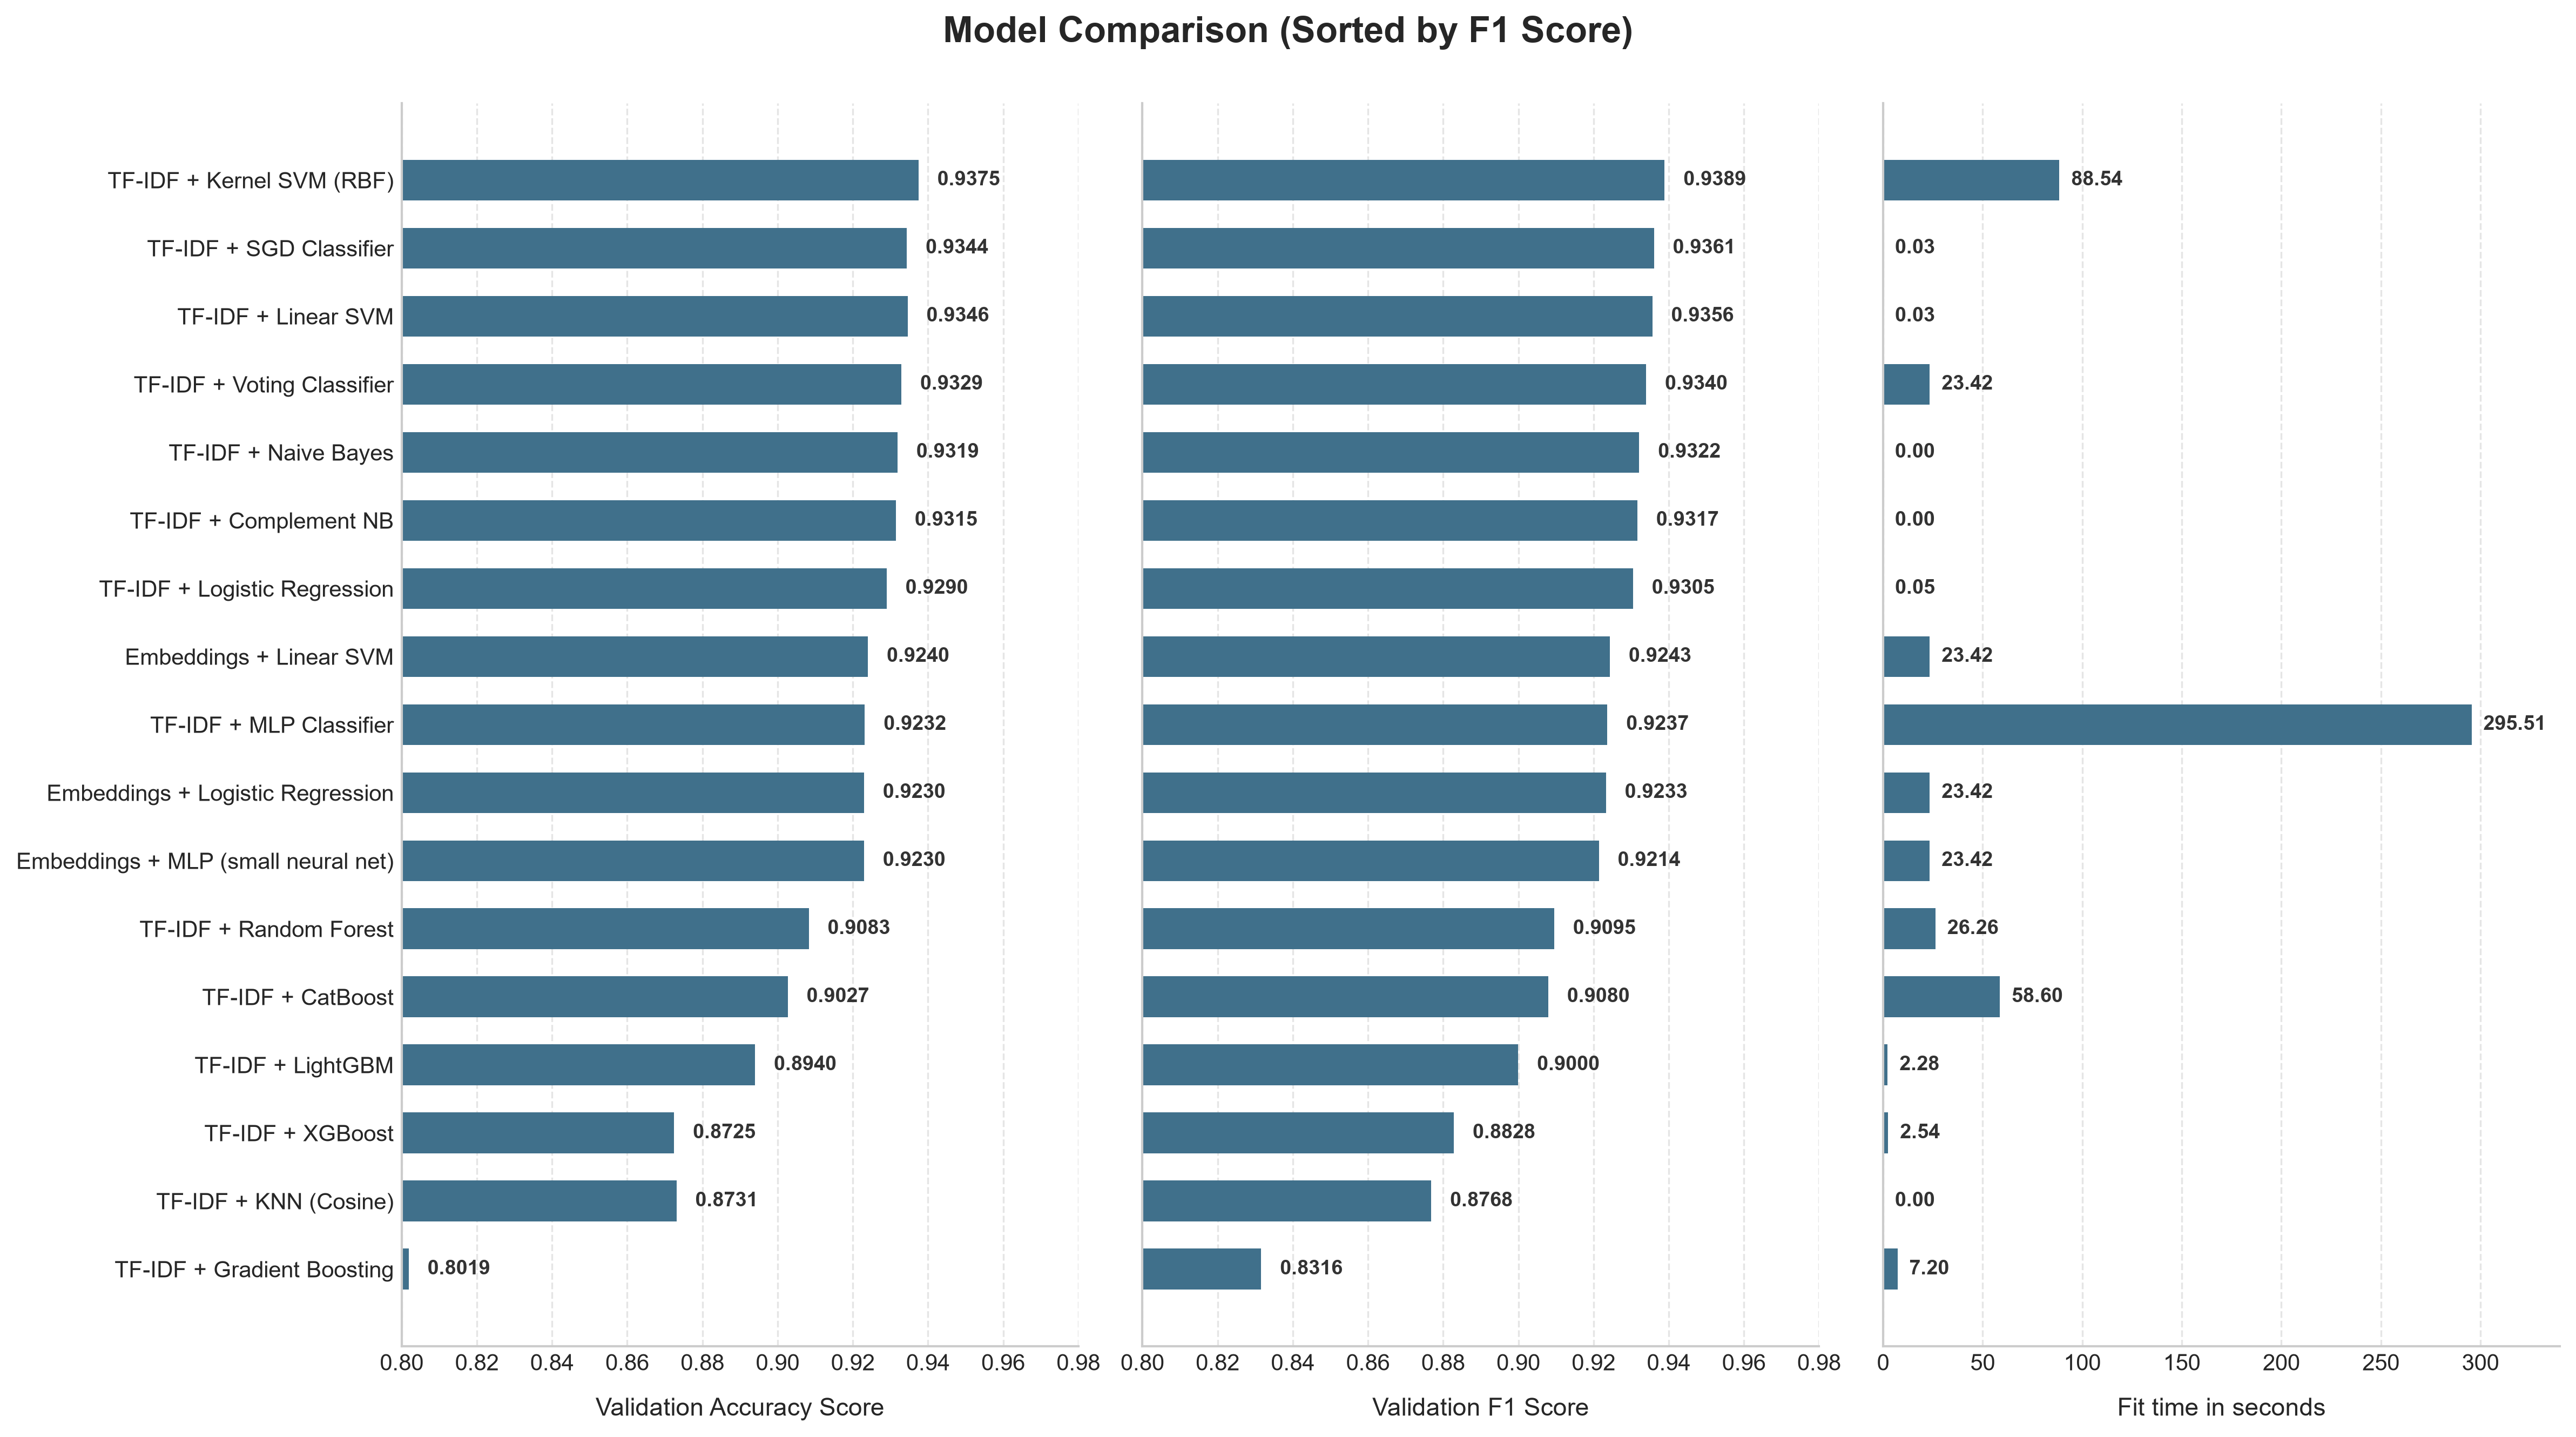

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("seaborn-v0_8-whitegrid" if "seaborn-v0_8-whitegrid" in plt.style.available else "default")

# Define metrics, labels, x-limits, and formatters for each subplot
metrics_config = [
    {
        "col": "Accuracy",
        "xlabel": "Validation Accuracy Score",
        "fmt": "{:.4f}",
        "xlim": (0.80, 0.98),
        "offset": 0.005
    },
    {
        "col": "F1",
        "xlabel": "Validation F1 Score",
        "fmt": "{:.4f}",
        "xlim": (0.80, 0.98),
        "offset": 0.005
    },
    {
        "col": "Fit time",
        "xlabel": "Fit time in seconds",
        "fmt": "{:.2f}",
        "xlim": (0, comparison["Fit time"].max() * 1.15),
        "offset": comparison["Fit time"].max() * 0.02
    }
]

# 1. Sort dataframe by primary metric (e.g., Accuracy or F1) so model order is consistent
df_sorted = comparison.sort_values(by="F1", ascending=True)

# 2. Create 1 row x 3 columns figure
fig, axes = plt.subplots(1, 3, figsize=(16, 9), dpi=300, sharey=True)

for ax, config in zip(axes, metrics_config):
    bars = ax.barh(
        df_sorted["Model"], 
        df_sorted[config["col"]], 
        color="#40708b", 
        height=0.6, 
        edgecolor="none"
    )
    
    # Annotate bar values
    for bar in bars:
        width = bar.get_width()
        ax.text(
            width + config["offset"], 
            bar.get_y() + bar.get_height() / 2, 
            config["fmt"].format(width), 
            va="center", 
            ha="left", 
            fontsize=9, 
            fontweight="bold", 
            color="#333333"
        )
        
    # Axis formatting
    ax.set_xlabel(config["xlabel"], fontsize=11, labelpad=10, fontweight="medium")
    if config["xlim"]:
        ax.set_xlim(config["xlim"])
        
    # Styling spines & grid lines
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_color("#cccccc")
    ax.spines["bottom"].set_color("#cccccc")
    ax.xaxis.grid(True, linestyle="--", alpha=0.5, color="#cccccc")
    ax.yaxis.grid(False)

# Title for the combined figure
fig.suptitle("Model Comparison (Sorted by F1 Score)", fontsize=16, fontweight="bold", y=0.98)

plt.tight_layout()
plt.subplots_adjust(top=0.92) # Leave space for top title
plt.show()

**What to expect / how to interpret this:** for short texts like news
headlines, TF-IDF (especially with bigrams) often matches or slightly beats
averaged word embeddings. Averaging word vectors throws away word order and
dilutes the signal from rare, highly distinctive words -- exactly the kind
of signal TF-IDF is built to preserve. Word embeddings tend to show a
bigger advantage on longer documents, or when using contextual embeddings
(like BERT) rather than static averaged ones. Whichever approach scores
best in *your* run is picked out automatically below.

## 6. Retrain the best model on all training data, and predict the test set

In [16]:
tfidf_candidates = tfidf_results.copy()
tfidf_candidates["source"] = "tfidf"

emb_candidates = pd.DataFrame([
    {"model": name, "family": "Embeddings", "accuracy": acc, "f1": f1, "source": "embeddings"}
    for name, (model, acc, f1) in emb_results.items()
])

all_candidates = pd.concat([tfidf_candidates, emb_candidates], ignore_index=True)
best_row = all_candidates.sort_values("f1", ascending=False).iloc[0]

use_embeddings = best_row["source"] == "embeddings"
sub_name = best_row["model"]
print(f"Selected model: {'Embeddings' if use_embeddings else 'TF-IDF'} + {sub_name}  (f1={best_row['f1']:.4f})")

# Reuse the already-instantiated model object from cell 12/17 instead of a separate
# lookup dict -- sklearn's .fit() fully resets a model's internal state, so calling
# .fit() again on the full dataset (next cell) just retrains it. No second model list
# to keep in sync with cell 12.
if use_embeddings:
    final_model = emb_results[sub_name][0]
else:
    final_model = tfidf_models[sub_name]


Selected model: TF-IDF + Kernel SVM (RBF)  (f1=0.9389)


In [17]:
# Retrain on the FULL training set (train_df), not just the 85% train_idx split used for model comparison
y_full = train_df["label"].astype(int).values

if use_embeddings:
    # Rebuild doc embeddings for ALL training rows and for the test set, reusing the word vectors (word_vecs_n / word2id) learned earlier from the train_idx vocabulary.
    X_full_feat = np.vstack(train_df["tokens"].apply(doc_embedding).values)
    X_test_feat = np.vstack(test_df["tokens"].apply(doc_embedding).values)
else:
    # Refit TF-IDF on the full training set (previously only fit on the train_idx split),
    # then transform the test set with that same fitted vectorizer.
    tfidf_final = TfidfVectorizer(**TFIDF_PARAMS)
    X_full_feat = tfidf_final.fit_transform(train_df["clean_text"])
    X_test_feat = tfidf_final.transform(test_df["clean_text"])

# .fit() resets a model's internal state, so this fully retrains `final_model` on all the training data rather than just continuing from the train_idx fit.
final_model.fit(X_full_feat, y_full)
test_preds = final_model.predict(X_test_feat)

print(f"Generated {len(test_preds)} predictions. Distribution: {pd.Series(test_preds).value_counts().to_dict()}")


Generated 9984 predictions. Distribution: {1: 5314, 0: 4670}


## 7. Save predictions in the original file format

In [18]:
output_df = pd.DataFrame({"label": test_preds, "text": test_df["text"]})

# Match the original file exactly: tab-separated, no header, UTF-8 BOM, CRLF line endings
output_df.to_csv(
    "../dataset/testing_data_predictions.csv",
    sep="\t", header=False, index=False,
    encoding="utf-8-sig", lineterminator="\r\n",
)
print("Saved testing_data_predictions.csv")


Saved testing_data_predictions.csv


In [19]:
testing_data_predictions = load_data('../dataset/testing_data_predictions.csv')

In [20]:
testing_data_predictions

,label,text
0,0,copycat muslim terrorist arrested with assault...
1,0,wow! chicago protester caught on camera admits...
2,1,germany's fdp look to fill schaeuble's big shoes
3,0,mi school sends welcome back packet warning ki...
4,1,u.n. seeks 'massive' aid boost amid rohingya '...
...,...,...
9979,0,boom! fox news leftist chris wallace attempts ...
9980,0,here it is: list of democrat hypocrites who vo...
9981,1,new fires ravage rohingya villages in northwes...
9982,0,meals on wheels shuts the lyin‚ lefties up wit...
